# BTC CTA Strategy: Momentum × Funding Rate × Order-Flow

**What:** Trend-following strategy that automatically sizes Bitcoin positions based on momentum, order flow, and crowding.

**Three Signals:**
- **Momentum (75%):** 3M/6M/12M risk-adjusted returns — primary alpha source
- **Order Flow (25%):** 21-day z-score of taker buy ratio — trend corroboration
- **Funding Rate:** Size modifier only (reduce when crowded, increase when shorts crowded)

## 1 · Data Collection

In [39]:
import requests
import pandas as pd
from datetime import datetime, timezone

SYMBOL = 'BTCUSDT'
START_DATE = '2020-01-01'
DATA_PATH = 'btcusdt_1d.csv'

def download_btc_daily(path=DATA_PATH):
    url = 'https://api.binance.com/api/v3/klines'
    t0 = int(datetime.strptime(START_DATE, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)
    now = int(datetime.now(timezone.utc).timestamp() * 1000)

    rows, cur = [], t0
    while cur <= now:
        data = requests.get(url, params={'symbol': SYMBOL, 'interval': '1d', 'startTime': cur, 'limit': 1000}).json()
        if not data:
            break
        rows.extend(data)
        last = int(data[-1][0])
        print(f'  {len(rows):,} candles  {datetime.fromtimestamp(last/1000, timezone.utc):%Y-%m-%d}', end='\r')
        if len(data) < 1000:
            break
        cur = last + 86_400_000

    cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
            'quote_vol', 'n_trades', 'taker_buy_base', 'taker_buy_quote', 'ignore']
    keep = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'taker_buy_base']

    df = pd.DataFrame(rows, columns=cols)[keep].copy()
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms', utc=True).dt.tz_localize(None)
    df[keep[1:]] = df[keep[1:]].apply(pd.to_numeric)
    df.to_csv(path, index=False)
    print(f'\nSaved {len(df):,} rows → {path}  [{df["open_time"].iloc[0]:%Y-%m-%d} → {df["open_time"].iloc[-1]:%Y-%m-%d}]')
    return df.set_index('open_time')

download_btc_daily()

  2,244 candles  2026-02-21
Saved 2,244 rows → btcusdt_1d.csv  [2020-01-01 → 2026-02-21]


,open,high,low,close,volume,taker_buy_base
open_time,,,,,,
2020-01-01,7195.24,7255.00,7175.15,7200.85,16792.388165,8946.955535
2020-01-02,7200.77,7212.50,6924.74,6965.71,31951.483932,15141.611340
2020-01-03,6965.49,7405.00,6871.04,7344.96,68428.500451,35595.496273
2020-01-04,7345.00,7404.00,7272.21,7354.11,29987.974977,16369.382248
2020-01-05,7354.19,7495.00,7318.00,7358.75,38331.085604,19455.369564
...,...,...,...,...,...,...
2026-02-17,68892.43,69241.50,66621.06,67503.52,16489.069210,7538.451070
2026-02-18,67503.52,68476.22,65870.00,66461.00,15492.438390,7895.057070
2026-02-19,66461.00,67320.00,65631.83,67003.73,14542.269880,7106.707410


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
from datetime import datetime

np.random.seed(42)

DATA_PATH = 'btcusdt_1d.csv'

daily = pd.read_csv(DATA_PATH)
daily['open_time'] = pd.to_datetime(daily['open_time'])
daily.set_index('open_time', inplace=True)
daily = daily.astype(float)

daily['taker_buy_ratio'] = daily['taker_buy_base'] / daily['volume'].replace(0, np.nan)

print(f'Price  : {len(daily)} daily bars  [{daily.index[0].date()} -> {daily.index[-1].date()}]')
daily.tail(3)

Price  : 2244 daily bars  [2020-01-01 -> 2026-02-21]


,open,high,low,close,volume,taker_buy_base,taker_buy_ratio
open_time,,,,,,,
2026-02-19,66461.00,67320.00,65631.83,67003.73,14542.26988,7106.70741,0.488693
2026-02-20,67003.73,68318.39,66280.20,68020.01,35351.87091,15001.46034,0.424347
2026-02-21,68020.00,68314.54,67534.69,68198.39,4126.77573,2108.73946,0.510990


In [41]:
# Funding Rates: Binance BTCUSDT-PERP
import requests
from datetime import datetime

FUNDING_PATH = 'btcusdt_funding.csv'

def fetch_funding_rates(symbol='BTCUSDT', path=FUNDING_PATH):
    url = 'https://fapi.binance.com/fapi/v1/fundingRate'
    records, start_ms = [], int(datetime(2020, 12, 31).timestamp() * 1000)
    
    while True:
        data = requests.get(url, params={'symbol': symbol, 'startTime': start_ms, 'limit': 1000}).json()
        if not data:
            break
        records.extend(data)
        if len(data) < 1000:
            break
        start_ms = int(data[-1]['fundingTime']) + 1
    
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['fundingTime'], unit='ms').dt.normalize()
    df['rate'] = df['fundingRate'].astype(float)
    out = (df.groupby('date')['rate'].sum() * 365).rename('fr_ann').reset_index()
    out.to_csv(path, index=False)
    print(f'Saved {len(out):,} rows → {path}')
    return out.set_index('date')['fr_ann']

fr = fetch_funding_rates()

# Only use funding data where it exists (no forward-fill imputation)
fr_daily = fr.reindex(daily.index)
first_fr_date = fr_daily.first_valid_index()

print(f'\nFunding: {fr_daily.notna().sum()} obs  [{fr.index[0].date()} -> {fr.index[-1].date()}]')
print(f'WARNING: Backtest will only use data from {first_fr_date.date()} onwards')
print(f'         ({(daily.index[0] - first_fr_date).days} days of warmup excluded)')
print(fr_daily.describe().round(3).to_string())

Saved 1,880 rows → btcusdt_funding.csv

Funding: 1880 obs  [2020-12-30 -> 2026-02-21]
         (-364 days of warmup excluded)
count    1880.000
mean        0.117
std         0.206
min        -0.931
25%         0.034
50%         0.081
75%         0.110
max         1.776


## 2 · Signal Construction

### Pipeline
```
raw_direction = 0.75 × momentum + 0.25 × orderflow  [−1, +1]
raw_signal = raw_direction × fr_scale                [−1, +1]
position = raw_signal × vol_scalar (1-day lag)       [−2, +2]
```

### Signal 1: Multi-Horizon Momentum (TSMOM)

`mom_h = clip(return_h / (vol_h × √h) / 3, −1, +1)`

Risk-adjusted return over 3M/6M/12M, normalized by volatility. Average across three horizons to avoid overfitting.

### Signal 2: Funding Rate → Size Modifier

`fr_scale = clip(1.0 − fr_smooth × 1.5, 0.25, 1.40)`

Crowded longs (high funding) → reduce size. Crowded shorts (negative funding) → increase size. Direction unchanged.

### Signal 3: Taker Order-Flow Imbalance

`ofi = clip(z_score(taker_buy_ratio, 21d) / 2, −1, +1)`

21-day z-score of taker buy ratio. Trends with momentum; confirms uptrends/downtrends.

In [42]:
ANN = 365
MOMENTUM_LOOKBACKS = (91, 182, 365) 
MOMENTUM_CLIP = 3.0                 
FR_MULTIPLIER = 1.5                  # Converts funding rate to size scalar; higher = more sensitive to crowding
FR_SMOOTH_WINDOW = 7          
TARGET_VOL = 0.60                    
MAX_LEV = 2.0                       

def calculate_momentum(close, lookbacks=MOMENTUM_LOOKBACKS):
    daily_ret = close.pct_change()
    momentum_signals = [
        (close.pct_change(h) / (daily_ret.rolling(h).std() * np.sqrt(h)).replace(0, np.nan)
         ).clip(-MOMENTUM_CLIP, MOMENTUM_CLIP) / MOMENTUM_CLIP
        for h in lookbacks
    ]
    return pd.concat(momentum_signals, axis=1).mean(axis=1).rename('momentum')


def calculate_funding_scale(fr_ann, smooth_window=FR_SMOOTH_WINDOW, clip_lo=0.25, clip_hi=1.40):
    # Mapping: +50% funding → 0.25x size; -20% funding → 1.30x size
    fr_smooth = fr_ann.rolling(smooth_window).mean()
    scale = 1.0 - fr_smooth * FR_MULTIPLIER
    return scale.clip(clip_lo, clip_hi).rename('fr_scale')


def calculate_orderflow(taker_buy_ratio, lookback=21):
    zscore = (taker_buy_ratio - taker_buy_ratio.rolling(lookback).mean()) / \
             taker_buy_ratio.rolling(lookback).std().replace(0, np.nan)
    return (zscore / 2).clip(-1, 1).rename('orderflow')


momentum_signal = calculate_momentum(daily['close'])
orderflow_signal = calculate_orderflow(daily['taker_buy_ratio'])
funding_scale = calculate_funding_scale(fr_daily)

print('Signal summary (daily):')
pd.DataFrame({'Momentum': momentum_signal, 'OrderFlow': orderflow_signal,
              'Funding Scale': funding_scale}).describe().round(3)

Signal summary (daily):


,Momentum,OrderFlow,Funding Scale
count,2153.000,2224.000,1874.000
mean,0.284,-0.005,0.847
std,0.375,0.481,0.181
min,-0.427,-1.000,0.250
25%,-0.019,-0.348,0.836
50%,0.280,-0.001,0.899
75%,0.522,0.332,0.941
max,1.000,1.000,1.282


In [43]:
TARGET_VOL = 0.60
MAX_LEV = 2.0
TC_PER_SIDE = 5 / 10_000  

raw_direction = (0.75 * momentum_signal + 0.25 * orderflow_signal).clip(-1, 1)
raw_signal = (raw_direction * funding_scale).clip(-1, 1)

realized_vol = daily['close'].pct_change().rolling(21).std() * np.sqrt(ANN)
vol_scalar = (TARGET_VOL / realized_vol.replace(0, np.nan)).clip(0.2, 3.0)

position = (raw_signal * vol_scalar).clip(-MAX_LEV, MAX_LEV).shift(1)

# Only backtest from when funding data exists; exclude last incomplete candle
position = position[first_fr_date:daily.index[-2]]  

print('Position size distribution:')
print(position.describe().round(3).to_string())
print(f'\nLong  days : {(position > 0.05).sum()}')
print(f'Short days : {(position < -0.05).sum()}')
print(f'Flat  days : {(position.abs() <= 0.05).sum()}')
print(f'\nBacktest period: {position.index[0].date()} to {position.index[-1].date()}')

Position size distribution:
count    1872.000
mean        0.180
std         0.323
min        -0.972
25%        -0.034
50%         0.170
75%         0.375
max         1.249

Long  days : 1268
Short days : 434
Flat  days : 170

Backtest period: 2020-12-30 to 2026-02-20


## 3 · Backtest & Performance Metrics


In [44]:
TC = TC_PER_SIDE  # 5 bps applied to |position.diff()| correctly models one-way trade cost

daily_ret = daily['close'].pct_change()
# 1-day position lag captures realistic execution (t+1 open vs t close signal)
gross_ret = position * daily_ret.reindex(position.index)
# TC = |Δposition| × 5bps covers taker fee (~4bps) + market impact (~1bps)
tc_cost = position.diff().abs() * TC
net_ret = (gross_ret - tc_cost).dropna().rename('net')
btc_ret = daily_ret.reindex(net_ret.index).rename('btc')

def perf_stats(r, label, rf=0.04):
    r = r.dropna()
    n = len(r) / ANN
    c = (1 + r).cumprod()
    cagr = c.iloc[-1] ** (1/n) - 1
    vol = r.std() * np.sqrt(ANN)
    sharpe = (r.mean() - rf/ANN) / r.std() * np.sqrt(ANN)
    
    # Correct max drawdown formula
    dd = (c - c.cummax()) / c.cummax()
    mdd = dd.min()
    
    # Edge case: Handle division by zero if mdd ≈ 0
    calmar = cagr / abs(mdd) if abs(mdd) > 1e-6 else np.inf
    
    return pd.Series({
        'CAGR': f'{cagr:+.1%}',
        'Volatility': f'{vol:.1%}',
        'Sharpe Ratio': f'{sharpe:.2f}',
        'Max Drawdown': f'{mdd:.1%}',
        'Calmar Ratio': f'{calmar:.2f}' if calmar != np.inf else 'N/A',
        'Win Rate': f'{(r > 0).mean():.1%}',
    }, name=label)

metrics = pd.concat([
    perf_stats(net_ret, 'Strategy (Net)'),
    perf_stats(btc_ret, 'BTC Buy & Hold'),
], axis=1)

print('=' * 54)
print('  PERFORMANCE SUMMARY')
print(f'  Period: {net_ret.index[0].date()} to {net_ret.index[-1].date()}')
print(f'  Risk-free rate: 4.0% p.a.')
print(f'  Transaction cost: {TC*10000:.0f} bps/side')
print('=' * 54)
print(metrics.to_string())
print('=' * 54)

  PERFORMANCE SUMMARY
  Period: 2021-01-07 to 2026-02-20
  Risk-free rate: 4.0% p.a.
  Transaction cost: 5 bps/side
             Strategy (Net) BTC Buy & Hold
CAGR                 +12.1%         +12.7%
Volatility            18.7%          58.5%
Sharpe Ratio           0.49           0.43
Max Drawdown         -19.3%         -76.6%
Calmar Ratio           0.63           0.17
Win Rate              48.8%          49.6%


## 4 · Performance Metrics

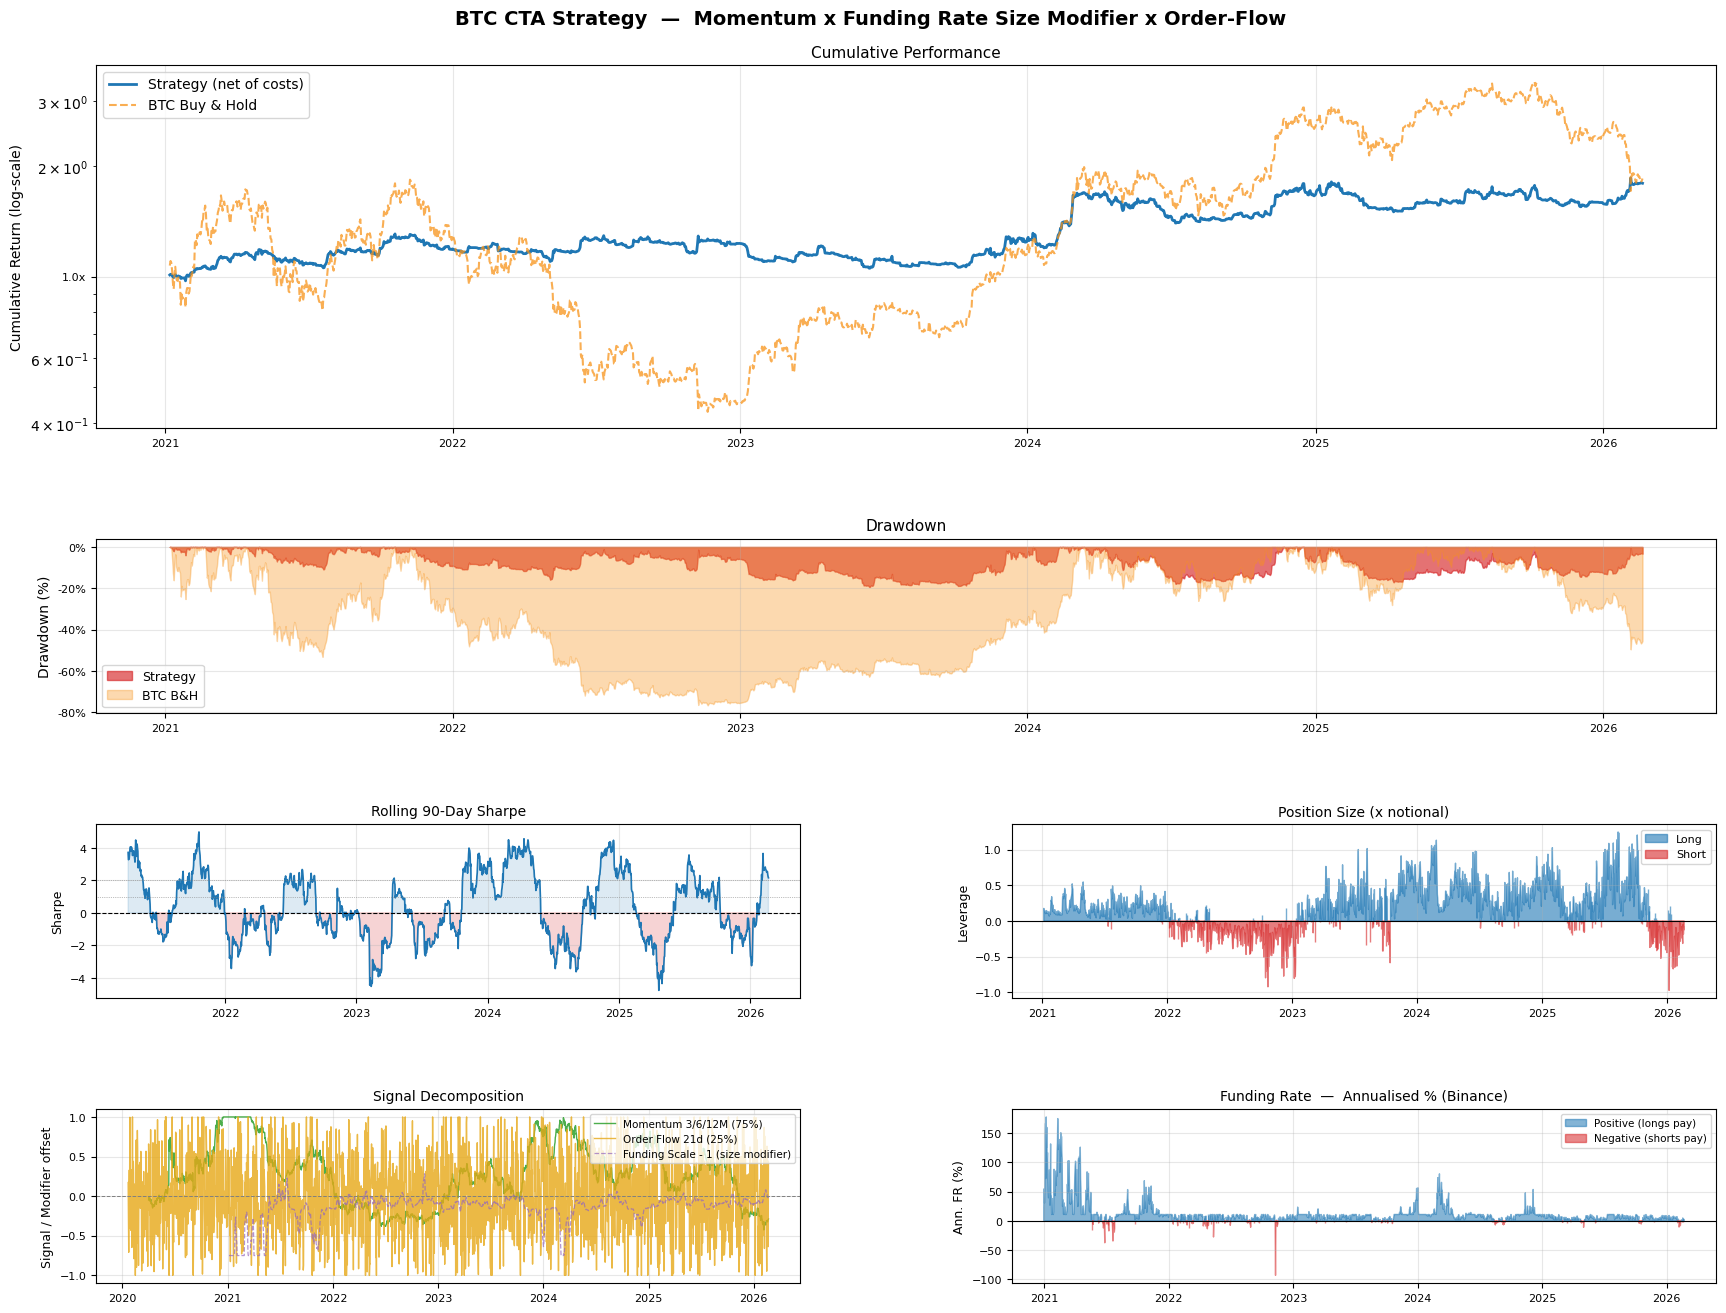

Chart saved → btc_cta_result.png


In [45]:
cumulative_strategy = (1 + net_ret).cumprod()
cumulative_btc = (1 + btc_ret).cumprod()
drawdown_strategy = (cumulative_strategy - cumulative_strategy.cummax()) / cumulative_strategy.cummax()
drawdown_btc = (cumulative_btc - cumulative_btc.cummax()) / cumulative_btc.cummax()
rolling_sharpe = net_ret.rolling(90).apply(
    lambda x: x.mean() / x.std() * np.sqrt(ANN) if x.std() > 0 else 0, raw=True)

BLUE, ORANGE, RED = '#1f77b4', '#F7931A', '#d62728'

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'BTC CTA Strategy  —  Momentum x Funding Rate Size Modifier x Order-Flow',
    fontsize=14, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(
    4, 2, figure=fig,
    height_ratios=[2.5, 1.2, 1.2, 1.2],
    hspace=0.50, wspace=0.30,
    left=0.07, right=0.97, top=0.94, bottom=0.07)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cumulative_strategy.index, cumulative_strategy.values, color=BLUE, lw=2.0, label='Strategy (net of costs)')
ax1.plot(cumulative_btc.index, cumulative_btc.values, color=ORANGE, lw=1.5, ls='--', alpha=0.75,
         label='BTC Buy & Hold')
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax1.set_ylabel('Cumulative Return (log-scale)', fontsize=10)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(alpha=0.3)
ax1.set_title('Cumulative Performance', fontsize=11)

ax2 = fig.add_subplot(gs[1, :])
ax2.fill_between(drawdown_strategy.index, drawdown_strategy.values * 100, 0,
                 color=RED, alpha=0.65, label='Strategy')
ax2.fill_between(drawdown_btc.index, drawdown_btc.values * 100, 0,
                 color=ORANGE, alpha=0.35, label='BTC B&H')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.set_ylabel('Drawdown (%)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_title('Drawdown', fontsize=11)

ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(rolling_sharpe.index, rolling_sharpe.values, color=BLUE, lw=1.2)
ax3.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                 where=rolling_sharpe > 0, color=BLUE, alpha=0.15)
ax3.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                 where=rolling_sharpe < 0, color=RED, alpha=0.20)
ax3.axhline(0, color='black', lw=0.8, ls='--')
ax3.axhline(1, color='gray', lw=0.5, ls=':')
ax3.axhline(2, color='gray', lw=0.5, ls=':')
ax3.set_title('Rolling 90-Day Sharpe', fontsize=10)
ax3.set_ylabel('Sharpe', fontsize=9)
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[2, 1])
ax4.fill_between(position.index, position.values, 0,
                 where=position >= 0, color=BLUE, alpha=0.60, label='Long')
ax4.fill_between(position.index, position.values, 0,
                 where=position < 0, color=RED, alpha=0.60, label='Short')
ax4.axhline(0, color='black', lw=0.8)
ax4.set_title('Position Size (x notional)', fontsize=10)
ax4.set_ylabel('Leverage', fontsize=9)
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[3, 0])
ax5.plot(momentum_signal.index, momentum_signal.values, color='#2ca02c', lw=1.0, alpha=0.85,
         label='Momentum 3/6/12M (75%)')
ax5.plot(orderflow_signal.index, orderflow_signal.values, color='#e6a817', lw=1.0, alpha=0.80,
         label='Order Flow 21d (25%)')
ax5.plot(funding_scale.index, funding_scale.values - 1.0, color='#9467bd', lw=0.9, alpha=0.70,
         ls='--', label='Funding Scale - 1 (size modifier)')
ax5.axhline(0, color='gray', lw=0.7, ls='--')
ax5.set_title('Signal Decomposition', fontsize=10)
ax5.set_ylabel('Signal / Modifier offset', fontsize=9)
ax5.legend(fontsize=7.5, ncol=1, loc='upper right')
ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[3, 1])
ax6.fill_between(fr_daily.index, fr_daily.values * 100, 0,
                 where=fr_daily >= 0, color=BLUE, alpha=0.55,
                 label='Positive (longs pay)')
ax6.fill_between(fr_daily.index, fr_daily.values * 100, 0,
                 where=fr_daily < 0, color=RED, alpha=0.55,
                 label='Negative (shorts pay)')
ax6.axhline(0, color='black', lw=0.8)
ax6.set_title('Funding Rate  —  Annualised % (Binance)', fontsize=10)
ax6.set_ylabel('Ann. FR (%)', fontsize=9)
ax6.legend(fontsize=7.5)
ax6.grid(alpha=0.3)

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.tick_params(labelsize=8)

OUT = 'btc_cta_result.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {OUT}')

## 5 · Discussion

### Expected Behavior by Regime

| Regime | BTC Return | Strategy Response |
|--------|-----------|-------------------|
| 2021 bull | +300% | Long, reduced size when funding elevated |
| 2022 bear | −75% | Short (momentum lags by 3M) |
| 2023 recovery | +150% | Flip long as momentum establishes |
| 2024 ATH | +120% | Fully long |

### Design Rationale

- **3M/6M/12M lookbacks:** Capture macro trends, filter intra-month noise
- **Funding as size modifier (not direction):** Avoids contrarian shorts during sustained bull runs